# Homework 7: Machine Learning Fundamentals and Support Vector Machines

**F&W ECOL 458 — Environmental Data Science**

**[Ines Lopez-Silvero]**

---

### Instructions

- Complete all cells marked with `# YOUR CODE HERE` or `# YOUR ANSWER HERE`.
- For written responses, type your answer in the markdown cells provided.
- Do not delete any existing code or markdown cells.
- Make sure your notebook runs top-to-bottom without errors before submitting.



---
## Setup

Run this cell first to import all required libraries.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# For reproducibility
np.random.seed(42)


---
## Problem 1: Supervised Learning Concepts (15 pts)

Answer the following questions in the markdown cells provided. Each answer should be 2–4 sentences.


### 1a (5 pts)
A researcher has GPS collar data for 200 elk, recording each animal's location, elevation, slope, distance to water, NDVI, and season. She knows whether each elk was resting or foraging at each time step. She wants to build a model that predicts behavior (resting vs. foraging) for new GPS fixes.

Is this a **classification** or **regression** problem? Is it **supervised** or **unsupervised**? Explain briefly.


*The model should be supervised regression because our goal is to predict behaviors, resting vs. foraging. It is looking to predict a continous result.*


### 1b (10 pts)
A colleague trains a machine learning model on a stream-temperature dataset and reports 99.5% accuracy on the training data but only 71% on the test data. What is the most likely problem, and what are the strategies to address it (list two)?


*The problem most likely is that the model is overfitting the points because it recognizes specific data.One way you can address it is through adjusting the gamma so that the model doesn't look at every specific piece of data. A second strategy could be increasing training points so there are too many points for the model to memorize.*


---
## Problem 2: Linear Regression (20 pts)

We will use the **California Housing** dataset to predict median house values from features like median income, house age, and geographic coordinates. Although this is not an ecological dataset, the regression workflow is identical to what you would use for predicting, e.g., aboveground biomass from remote-sensing features.


### 2a (10 pts)
Load the dataset, explore its structure, and split it into training (75%) and test (25%) sets. Print the feature names and the shape of the training and test arrays.


In [3]:
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # median house value in $100,000s

# Explore
print("Feature names:", list(X.columns))
print("Dataset shape:", X.shape)
print("Target range: ", f"{y.min():.2f} to {y.max():.2f}")
print()

# ── Split into train / test ──
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.25, random_state=42
)

# Print shapes to verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset shape: (20640, 8)
Target range:  0.15 to 5.00

X_train shape: (15480, 8)
X_test shape: (5160, 8)
y_train shape: (15480,)
y_test shape: (5160,)


### 2b (10 pts)
Train a `LinearRegression` model on the training set. Report the MSE and $R^2$ on the **test** set. Create a scatter plot of predicted vs. actual values with a 1:1 reference line.


MSE: 0.5
R^2: 0.591


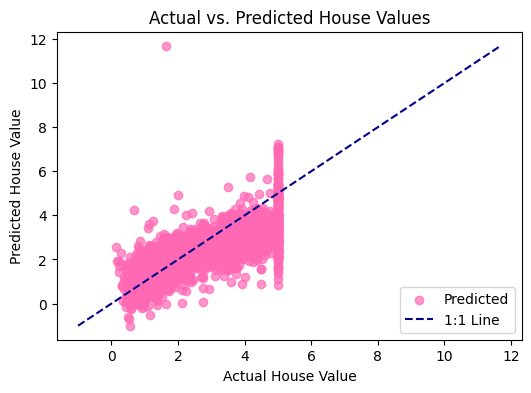

In [5]:
# ── Train the model ──
model=LinearRegression()
model.fit(X_train, y_train)

y_pred=model.predict(X_test)


# ── Evaluate on test set ──
print(f"MSE: {mean_squared_error(y_test,y_pred):.1f}")
print(f"R^2: {r2_score(y_test,y_pred):.3f}")


# ── Scatter plot: predicted vs. actual ──
fig,ax=plt.subplots(figsize=(6,4))
ax.scatter(y_test, y_pred, color="hotpink", alpha=0.7, label="Predicted")

# Add a 1:1 reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color="darkblue", linestyle="--", label="1:1 Line")

ax.set_xlabel("Actual House Value")
ax.set_ylabel("Predicted House Value")
ax.set_title("Actual vs. Predicted House Values")
ax.legend()
plt.show()

---
## Problem 3: Logistic Regression and Classification Evaluation (30 pts)

We will use the **Wine** dataset, which contains chemical analysis results for 178 wines from three Italian cultivars. This is a multi-class classification problem, similar to classifying vegetation types from spectral data.


### 3a (8 pts)
Load the Wine dataset, standardize the features using `StandardScaler`, and split into training (70%) and test (30%) sets with `stratify=y`. Print the class names and the number of samples per class in the training set.


In [8]:
# ── Load the Wine dataset ──
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Classes:", wine.target_names)
print("Features:", wine.feature_names)
print()

# ── Train/test split (70/30, stratified) ──
X_train, X_test, y_train, y_test=train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

# ── Standardize features ──
# Standardize features AFTER splitting to prevent data leakage from test set
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)


# ── Print class distribution in training set ──
print("Training set class distribution:")
classes, counts=np.unique(y_train, return_counts=True) # Corrected typo: counuts -> counts
for cls, count in zip(classes, counts):
  print(f"Class {cls} ({wine.target_names[cls]}): {count} samples")


Classes: ['class_0' 'class_1' 'class_2']
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Training set class distribution:
Class 0 (class_0): 41 samples
Class 1 (class_1): 50 samples
Class 2 (class_2): 33 samples


### 3b (8 pts)
Train a `LogisticRegression(max_iter=500)` classifier. Print the overall accuracy and the full `classification_report` (precision, recall, F1 per class) on the **test** set.


In [11]:
# ── Train logistic regression ──
logreg=LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)


# ── Predict on test set ──
y_pred=logreg.predict(X_test_sc)


# ── Accuracy and classification report ──
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report
accuracy=metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))





Accuracy: 62.96%

Classification Report:
              precision    recall  f1-score   support

     class_0       0.58      0.39      0.47        18
     class_1       0.52      0.57      0.55        21
     class_2       0.79      1.00      0.88        15

    accuracy                           0.63        54
   macro avg       0.63      0.65      0.63        54
weighted avg       0.62      0.63      0.61        54



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 3c (7 pts)
Plot the confusion matrix for your logistic regression classifier using `ConfusionMatrixDisplay`. Which pair of classes (if any) is most often confused?


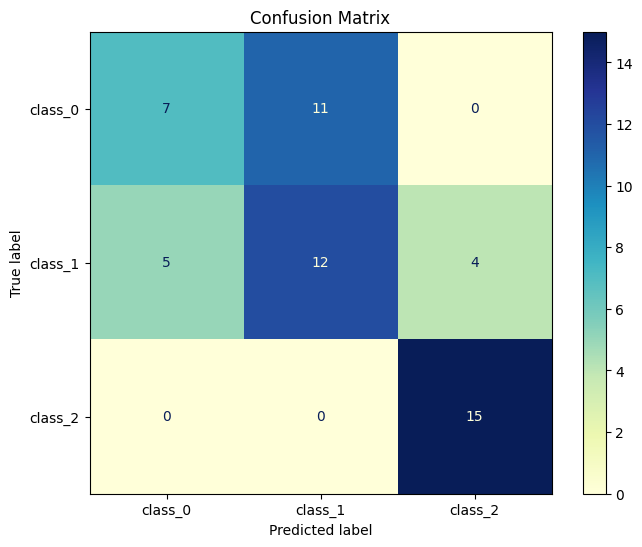

In [19]:
# ── Confusion matrix plot ──
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax=plt.subplots(figsize=(8,6))

cmd = ConfusionMatrixDisplay.from_estimator(
    logreg, X_test_sc, y_test, display_labels=wine.target_names,cmap="YlGnBu",ax=ax
)

ax.set_title ("Confusion Matrix")
plt.show()

### 3d (7 pts)
Perform **5-fold cross-validation** on the full dataset (using the standardized features) and report the mean and standard deviation of accuracy. How does the cross-validated accuracy compare to your single train/test split accuracy from 3b? Why might they differ? (2–3 sentences)


*The pair of classes that are the most confsued are class 0 and class 1*

In [20]:
# ── 5-fold cross-validation ──
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler


logreg_cv=LogisticRegression(max_iter=500)
X_scaled=StandardScaler().fit_transform(wine.data)
scores=cross_val_score(logreg_cv, X_scaled, wine.target, cv=5)

print(f"All 5 Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.2%}")
print(f"Std Accuracy: {scores.std():.4f}")




All 5 Scores: [0.97222222 0.97222222 1.         1.         1.        ]
Mean Accuracy: 98.89%
Std Accuracy: 0.0136


* The cross-validated accruracy is probably better because unlike the single/train test, the cross-validated accurcacy can evaluate the model on muiltple different groups of the data. This removes any biases.*


---
## Problem 4: SVM with Different Kernels (35 pts)

We will continue with the Wine dataset to explore how SVMs perform with different kernels and hyperparameters.


### 4a (8 pts)
Train three SVM classifiers on the **standardized** training data from Problem 3:
1. Linear kernel, `C=1`
2. RBF kernel, `C=1`, `gamma='scale'`
3. RBF kernel, `C=100`, `gamma='scale'`

Report the test accuracy for each model.


In [22]:
# ── Train three SVM classifiers ──
svm_configs = [
    {"kernel": "linear", "C": 1},
    {"kernel": "rbf",    "C": 1,   "gamma": "scale"},
    {"kernel": "rbf",    "C": 100, "gamma": "scale"},
]

# YOUR CODE HERE — loop through configs, train, predict, and print accuracy
from sklearn.svm import SVC
for config in svm_configs:
    svm_model = SVC(**config)
    svm_model.fit(X_train_sc, y_train)
    y_pred = svm_model.predict(X_test_sc)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Results for Config: {config}")
    print(f"Accuracy: {accuracy:.4f}")
    print("-"*30)


Results for Config: {'kernel': 'linear', 'C': 1}
Accuracy: 0.9630
------------------------------
Results for Config: {'kernel': 'rbf', 'C': 1, 'gamma': 'scale'}
Accuracy: 0.9815
------------------------------
Results for Config: {'kernel': 'rbf', 'C': 100, 'gamma': 'scale'}
Accuracy: 0.9815
------------------------------


### 4b (12 pts)
For the RBF kernel, systematically test `C` values of `[0.01, 0.1, 1, 10, 100, 1000]` using **5-fold cross-validation** on the full standardized dataset. Plot mean cross-validated accuracy (with error bars showing ± 1 std) as a function of $C$ on a **log scale** x-axis.


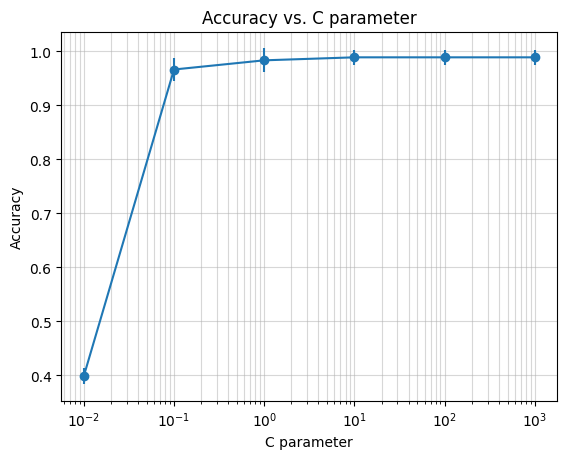

In [23]:
# ── C parameter sweep with cross-validation ──
C_values = [0.01, 0.1, 1, 10, 100, 1000]

# YOUR CODE HERE — for each C, run cross_val_score and store mean/std
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import numpy as np

means=[]
stds=[]
for c in C_values:
    svm_model = SVC(kernel="rbf", C=c, gamma="scale")
    scores = cross_val_score(svm_model, X_scaled, wine.target, cv=5)
    means.append(scores.mean())
    stds.append(scores.std())

# ── Plot: accuracy vs. C ──
plt.xscale('log')
plt.xlabel('C parameter')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. C parameter')
plt.grid(True, which="both", ls="-",alpha=0.5)
plt.errorbar(C_values, means, yerr=stds, fmt='o-')
plt.show()



### 4c (7 pts)
Based on your plot, which value of $C$ gives the best cross-validated accuracy? What happens to accuracy at very low and very high $C$ values? Explain in terms of the bias–variance tradeoff (3–4 sentences).


*The value of C with the best cross-validated accuracy would be C^3. The accuracy at low C values is very bad at around .4 accuracy. This represents high bias where the model is too simple and has a lot of errors because it doesnn't understand the patterns of the data. The accuracy at high C values remain stable around 1.0 accuracy. This can mean overfitting which means the model can memorize the specific patterns resulting in high test accuracy.*


### 4d (8 pts)
Using your best $C$ value, train a final RBF SVM on the full training set and generate the confusion matrix on the test set. Compare the confusion pattern to the logistic regression result from Problem 3c. Does the SVM improve classification for the class pair that was most often confused? (2–3 sentences)


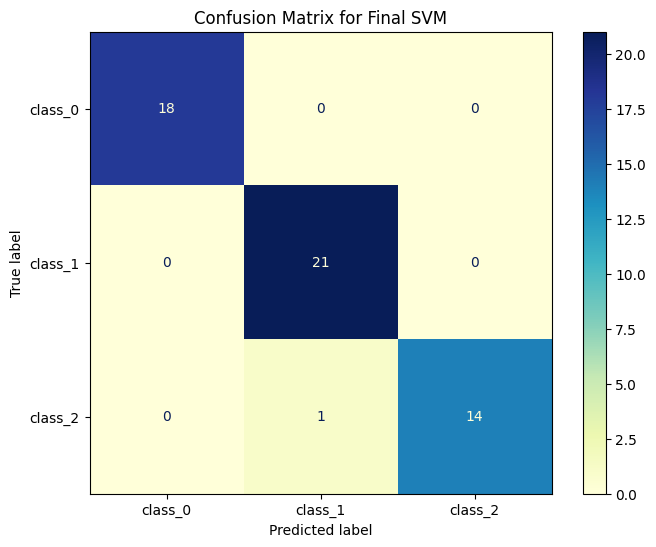

In [24]:
# ── Final SVM with best C ──
final_svm=SVC(kernel='rbf',C=100, gamma='scale')
final_svm.fit(X_train_sc, y_train)




# ── Confusion matrix ──
fig, ax=plt.subplots(figsize=(8,6))
cmd = ConfusionMatrixDisplay.from_estimator(
    final_svm, X_test_sc, y_test, display_labels=wine.target_names,cmap="YlGnBu",ax=ax
)

ax.set_title ("Confusion Matrix for Final SVM")
plt.show()




*The RBF SVM improves classification perfomances compared to the Logistic Regression model. Insteatd of confusion in both class 0 and 1, the SVM model complelty fixes that Because logistic regression is linear it tried to draw a line over overlapping data. With RBF the model has better adaptability to the data.*


---
### Submission checklist

- [ ] All code cells run without errors (Kernel → Restart & Run All).
- [ ] All written-response cells are filled in.
- [ ] Plots have axis labels and titles.
- [ ] File is saved as `HW7_LastName_FirstName.ipynb`.